# Chronos-2 Training v1 - Multi-country Electricity Forecasting

Goal: build a Chronos-2 baseline on the same multi-country dataset used by TFT, then export metrics/artifacts for transfer experiments.

This notebook follows the TFT structure: config -> data prep -> train/val split -> forecasting -> metrics -> save artifacts.

In [23]:
# CELL 1 - IMPORTS & PATHS
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings('ignore')

BASE_DIR = Path('.')
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'training_data' / 'tft_premodel_dataset_EDA.csv'
OUT_DIR = BASE_DIR / 'checkpoint' / 'chronos2_v1'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Data path:', DATA_PATH)
print('Output dir:', OUT_DIR)

Torch version: 2.5.1+cu121
CUDA available: True
Data path: data\processed\training_data\tft_premodel_dataset_EDA.csv
Output dir: checkpoint\chronos2_v1


In [24]:
# CELL 2 - INSTALL / CHECK DEPENDENCIES
# Run this cell once. It installs Chronos if missing.
import sys
import subprocess
import importlib.util

REQUIRED_PACKAGES = [
    'chronos-forecasting',
    'transformers',
    'accelerate',
    'sentencepiece',
]

def ensure_packages(packages):
    missing = []
    for pkg in packages:
        module_name = 'chronos' if pkg == 'chronos-forecasting' else pkg.replace('-', '_')
        if importlib.util.find_spec(module_name) is None:
            missing.append(pkg)

    if not missing:
        print('All required packages are already installed.')
        return

    print('Installing missing packages:', missing)
    cmd = [sys.executable, '-m', 'pip', 'install', '-U'] + missing
    subprocess.check_call(cmd)
    print('Installation complete. If import still fails, restart kernel then rerun from Cell 1.')

ensure_packages(REQUIRED_PACKAGES)

All required packages are already installed.


In [25]:
# CELL 3 - CONFIG
CFG = {
    # Preferred Chronos-2 for benchmark (may fail with current chronos package).
    'model_id': 'amazon/chronos-2',
    # Lightweight fallback models to avoid large downloads / low disk issues.
    'fallback_model_ids': ['amazon/chronos-t5-tiny', 'amazon/chronos-t5-mini'],
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'torch_dtype': 'bfloat16' if torch.cuda.is_available() else 'float32',
    'max_encoder_length': 24,
    'prediction_length': 6,
    'val_cutoff_months': 12,
    'min_series_length': 30,
    'num_samples': 100,
    'quantiles': [0.1, 0.25, 0.5, 0.75, 0.9],
    'seed': 42,
    # Put HF cache inside project so you can monitor/clean it easily.
    'hf_cache_dir': str((Path('.') / 'checkpoint' / 'hf_cache').resolve()),
}

np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

for k, v in CFG.items():
    print(f'{k:<22}: {v}')

model_id              : amazon/chronos-2
fallback_model_ids    : ['amazon/chronos-t5-tiny', 'amazon/chronos-t5-mini']
device                : cuda
torch_dtype           : bfloat16
max_encoder_length    : 24
prediction_length     : 6
val_cutoff_months     : 12
min_series_length     : 30
num_samples           : 100
quantiles             : [0.1, 0.25, 0.5, 0.75, 0.9]
seed                  : 42
hf_cache_dir          : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\hf_cache


In [26]:
# CELL 4 - LOAD CHRONOS PIPELINE
import os
import shutil
import importlib.util
from pathlib import Path

if importlib.util.find_spec('chronos') is None:
    raise ModuleNotFoundError(
        "Module 'chronos' is not installed. Run Cell 2 first, then rerun this cell."
    )

from chronos import ChronosPipeline

cache_dir = Path(CFG.get('hf_cache_dir', './checkpoint/hf_cache'))
cache_dir.mkdir(parents=True, exist_ok=True)
os.environ['HF_HOME'] = str(cache_dir)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(cache_dir)
os.environ['TRANSFORMERS_CACHE'] = str(cache_dir)

dtype_map = {
    'float32': torch.float32,
    'bfloat16': torch.bfloat16,
    'float16': torch.float16,
}

models_to_try = [CFG['model_id']] + list(CFG.get('fallback_model_ids', []))
load_errors = []
pipeline = None
loaded_model_id = None

total, used, free = shutil.disk_usage(cache_dir.drive if cache_dir.drive else str(cache_dir))
print(f'Free disk before model load: {free / (1024**3):.2f} GB')
print('Model candidates:', models_to_try)

for candidate in models_to_try:
    try:
        print(f'Trying: {candidate}')
        pipeline = ChronosPipeline.from_pretrained(
            candidate,
            device_map=CFG['device'],
            dtype=dtype_map[CFG['torch_dtype']],
            cache_dir=str(cache_dir),
        )
        loaded_model_id = candidate
        break
    except Exception as e:
        load_errors.append((candidate, str(e)))
        print(f'Failed: {candidate}')
        print(f'  Reason: {e}')

if pipeline is None:
    raise RuntimeError(
        'All Chronos model candidates failed. '\
        'Free up disk space and retry, or use an even smaller model. '\
        f'Errors: {load_errors}'
    )

CFG['loaded_model_id'] = loaded_model_id
print('Chronos pipeline loaded:', loaded_model_id)
print('HF cache dir:', cache_dir)

Free disk before model load: 20.55 GB
Model candidates: ['amazon/chronos-2', 'amazon/chronos-t5-tiny', 'amazon/chronos-t5-mini']
Trying: amazon/chronos-2
Failed: amazon/chronos-2
  Reason: ChronosConfig.__init__() got an unexpected keyword argument 'input_patch_size'
Trying: amazon/chronos-t5-tiny
Chronos pipeline loaded: amazon/chronos-t5-tiny
HF cache dir: C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\hf_cache


In [27]:
# CELL 5 - DATA PREP (same idea as TFT)
TARGET_SERIES = [
    'Coal', 'Gas', 'Hydro', 'Solar', 'Wind',
    'Bioenergy', 'Nuclear', 'Other Fossil', 'Other Renewables',
]

df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df[df['series'].isin(TARGET_SERIES)].copy()

df = df.sort_values(['entity', 'series', 'date'])
df['group_id'] = df['entity'].astype(str) + '||' + df['series'].astype(str)
df['time_idx'] = df.groupby('group_id')['date'].rank(method='dense').astype(int) - 1

counts = df.groupby('group_id').size()
valid_groups = counts[counts >= CFG['min_series_length']].index
df = df[df['group_id'].isin(valid_groups)].copy()

print('Shape:', df.shape)
print('Groups:', df['group_id'].nunique())
print('Date range:', df['date'].min().date(), '->', df['date'].max().date())

Shape: (13859, 31)
Groups: 151
Date range: 2018-01-01 -> 2025-12-01


In [28]:
# CELL 6 - TRAIN/VAL SPLIT
max_time = int(df['time_idx'].max())
training_cutoff = max_time - CFG['val_cutoff_months']

train_df = df[df['time_idx'] <= training_cutoff].copy()
val_df = df[df['time_idx'] > training_cutoff].copy()

print('training_cutoff:', training_cutoff)
print('Train rows:', len(train_df))
print('Val rows:', len(val_df))

training_cutoff: 83
Train rows: 12451
Val rows: 1408


In [29]:
# CELL 7 - FORECAST HELPERS
def _run_quantile_forecast(pipeline, context_values, prediction_length, quantiles, num_samples):
    context = torch.tensor(context_values, dtype=torch.float32).unsqueeze(0)

    # API-compatible wrappers for different chronos versions
    if hasattr(pipeline, 'predict_quantiles'):
        try:
            q, mean = pipeline.predict_quantiles(
                context=context,
                prediction_length=prediction_length,
                quantile_levels=quantiles,
                num_samples=num_samples,
            )
        except TypeError:
            q, mean = pipeline.predict_quantiles(
                context,
                prediction_length,
                quantile_levels=quantiles,
            )
        return np.asarray(q)[0], np.asarray(mean)[0]

    if hasattr(pipeline, 'predict'):
        samples = pipeline.predict(
            context=context,
            prediction_length=prediction_length,
            num_samples=num_samples,
        )
        samples = np.asarray(samples)[0]
        mean = samples.mean(axis=0)
        q = np.quantile(samples, quantiles, axis=0).T
        return q, mean

    raise RuntimeError('No supported prediction method found on ChronosPipeline')


def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return np.mean(2.0 * np.abs(y_true - y_pred) / denom) * 100.0


def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-8) * 100.0

In [30]:
# CELL 8 - ROLLING VALIDATION FORECAST
rows = []

for gid, g in df.groupby('group_id'):
    g = g.sort_values('time_idx').reset_index(drop=True)
    max_idx = int(g['time_idx'].max())

    start_forecast_idx = training_cutoff + 1
    if start_forecast_idx > max_idx:
        continue

    context_window = CFG['max_encoder_length']

    for t in range(start_forecast_idx, max_idx + 1, CFG['prediction_length']):
        hist = g[g['time_idx'] < t]['generation_TWh'].values
        if len(hist) < context_window:
            continue

        context_vals = hist[-context_window:]

        q_preds, mean_pred = _run_quantile_forecast(
            pipeline=pipeline,
            context_values=context_vals,
            prediction_length=CFG['prediction_length'],
            quantiles=CFG['quantiles'],
            num_samples=CFG['num_samples'],
        )

        future_idx = list(range(t, min(t + CFG['prediction_length'], max_idx + 1)))
        g_future = g[g['time_idx'].isin(future_idx)].sort_values('time_idx')

        for j, (_, r) in enumerate(g_future.iterrows()):
            if j >= len(mean_pred):
                break
            rows.append({
                'group_id': gid,
                'entity': r['entity'],
                'series': r['series'],
                'date': r['date'],
                'time_idx': int(r['time_idx']),
                'y_true': float(r['generation_TWh']),
                'y_pred': float(mean_pred[j]),
                'q10': float(q_preds[j][0]) if q_preds.shape[1] > 0 else np.nan,
                'q25': float(q_preds[j][1]) if q_preds.shape[1] > 1 else np.nan,
                'q50': float(q_preds[j][2]) if q_preds.shape[1] > 2 else float(mean_pred[j]),
                'q75': float(q_preds[j][3]) if q_preds.shape[1] > 3 else np.nan,
                'q90': float(q_preds[j][4]) if q_preds.shape[1] > 4 else np.nan,
            })

pred_df = pd.DataFrame(rows).sort_values(['entity', 'series', 'date']).reset_index(drop=True)
print('Prediction rows:', len(pred_df))
pred_df.head()

Prediction rows: 1408


,group_id,entity,series,date,time_idx,y_true,y_pred,q10,q25,q50,q75,q90
0,Australia||Bioenergy,Australia,Bioenergy,2025-01-01,84,0.03,0.037527,0.020015,0.030022,0.040029,0.040029,0.051037
1,Australia||Bioenergy,Australia,Bioenergy,2025-02-01,85,0.02,0.033024,0.010007,0.020015,0.030022,0.040029,0.050037
2,Australia||Bioenergy,Australia,Bioenergy,2025-03-01,86,0.02,0.028283,0.010007,0.017513,0.025018,0.032524,0.040029
3,Australia||Bioenergy,Australia,Bioenergy,2025-04-01,87,0.01,0.027258,0.010007,0.020015,0.020015,0.030022,0.040029
4,Australia||Bioenergy,Australia,Bioenergy,2025-05-01,88,0.01,0.023470,0.010007,0.010007,0.020015,0.022517,0.041030


In [31]:
# CELL 9 - METRICS
if pred_df.empty:
    raise RuntimeError('No predictions generated. Check context length / split settings.')

from sklearn.metrics import r2_score

y_true = pred_df['y_true'].values
y_pred = pred_df['y_pred'].values

mae = float(np.mean(np.abs(y_true - y_pred)))
rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
smape_val = float(smape(y_true, y_pred))
wape_val = float(wape(y_true, y_pred))
r2_val = float(r2_score(y_true, y_pred))

print('Validation metrics (Chronos-2):')
print(f'  MAE   : {mae:.4f}')
print(f'  RMSE  : {rmse:.4f}')
print(f'  R2    : {r2_val:.4f}')
print(f'  SMAPE : {smape_val:.2f}%')
print(f'  WAPE  : {wape_val:.2f}%')

Validation metrics (Chronos-2):
  MAE   : 0.3207
  RMSE  : 0.6786
  R2    : 0.9708
  SMAPE : 28.07%
  WAPE  : 13.96%


In [32]:
# CELL 10 - SAVE ARTIFACTS
pred_path = OUT_DIR / 'chronos2_v1_val_predictions.csv'
metrics_path = OUT_DIR / 'chronos2_v1_metrics.json'
cfg_path = OUT_DIR / 'chronos2_v1_config.json'

pred_df.to_csv(pred_path, index=False)

effective_model_id = CFG.get('loaded_model_id', CFG['model_id'])

metrics = {
    'model_id_requested': CFG['model_id'],
    'model_id_loaded': effective_model_id,
    'mae': mae,
    'rmse': rmse,
    'r2': r2_val,
    'smape': smape_val,
    'wape': wape_val,
    'n_predictions': int(len(pred_df)),
    'train_groups': int(train_df['group_id'].nunique()),
    'train_date_range': [str(train_df['date'].min().date()), str(train_df['date'].max().date())],
    'val_date_range': [str(val_df['date'].min().date()), str(val_df['date'].max().date())],
}

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(CFG, f, indent=2, ensure_ascii=False)

print('Saved:', pred_path)
print('Saved:', metrics_path)
print('Saved:', cfg_path)
print('Requested model:', CFG['model_id'])
print('Loaded model   :', effective_model_id)

Saved: checkpoint\chronos2_v1\chronos2_v1_val_predictions.csv
Saved: checkpoint\chronos2_v1\chronos2_v1_metrics.json
Saved: checkpoint\chronos2_v1\chronos2_v1_config.json
Requested model: amazon/chronos-2
Loaded model   : amazon/chronos-t5-tiny


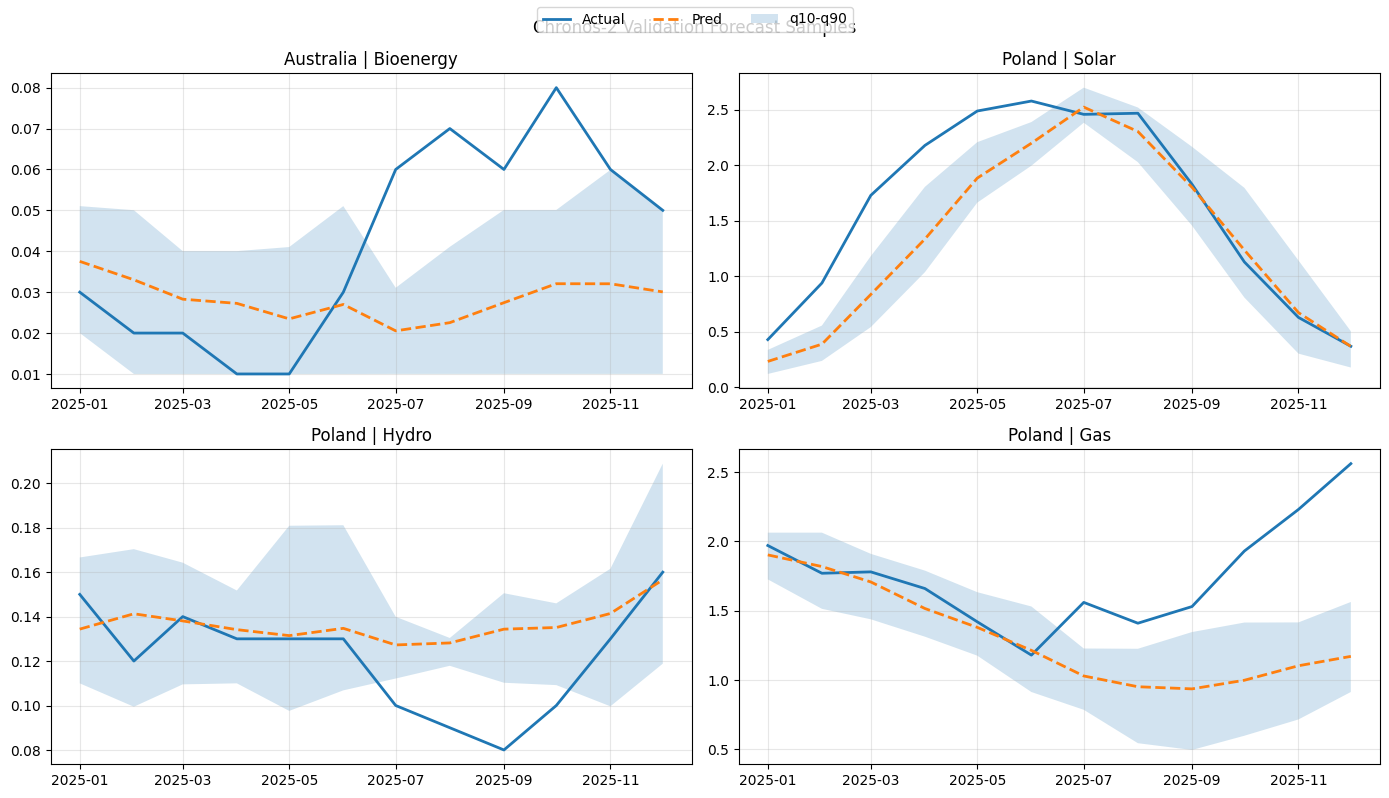

In [33]:
# CELL 11 - QUICK PLOT
import matplotlib.pyplot as plt

sample = pred_df.copy()
sample['entity_series'] = sample['entity'] + ' | ' + sample['series']
top_groups = sample['entity_series'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
for ax, name in zip(axes.flatten(), top_groups):
    sub = sample[sample['entity_series'] == name].sort_values('date')
    ax.plot(sub['date'], sub['y_true'], label='Actual', linewidth=2)
    ax.plot(sub['date'], sub['y_pred'], label='Pred', linewidth=2, linestyle='--')
    ax.fill_between(sub['date'], sub['q10'], sub['q90'], alpha=0.2, label='q10-q90')
    ax.set_title(name)
    ax.grid(alpha=0.3)

handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
fig.suptitle('Chronos-2 Validation Forecast Samples')
plt.tight_layout()
plt.show()